# Stage 2d — MESM calibration, extended to all seven Tier 1 experiments

`2c_calibrate_MESM.ipynb` calibrates the JAX SCM against MESM in two phases,
both fit against a single idealized experiment, `1pctCO2`:

1. **Carbon cycle** (emissions → concentration), fit against `1pctCO2`'s known
   1%/yr concentration ramp.
2. **Climate sensitivity** (concentration → temperature), fit against MESM's
   own **concentration-driven** ensemble mean for `1pctCO2`.

This notebook loads the output of `scripts/2d_calibrate_MESM_alt.py`, which
replaces step 2 with a joint Carbon+Climate fit against all seven real Tier 1
ScenarioMIP experiments (`historical`, `H-ext`, `M`, `ML`, `L`, `VLHO`,
`VLLO-ext`), run through the full emissions-driven pipeline. **No compute
happens in this notebook** — see the script's own module docstring for the
full reasoning; summarized here:

- **CO2-only, matching MESM's actual forcing.** MESM's real Tier 1 runs were
  themselves only ever forced with CO2 emissions — the same established scope
  `6d_scm_mesm_fidelity.py`/`6k_scm_mesm_fidelity_plot.ipynb` already use for
  Tier2/DECK/CS3. An earlier version of this script and notebook drove the SCM
  with real multi-agent (CO2+CH4+N2O+Sulfur+BC) Tier 1 emissions while scoring
  against that same CO2-only-forced MESM ground truth — a genuine input/target
  mismatch, not a deliberate joint multi-agent fit. Fixed: both the script and
  this notebook now use `agents=('CO2',)` throughout, so the calibration
  result below (`theta_tier1`) reflects a rerun against the corrected,
  CO2-only dataset — it supersedes the earlier multi-agent-mismatched result.
- **This run also adds DECK's `1pctCO2`/`2xCO2` directly into the training set** (`scripts/2d_calibrate_MESM_alt.py`'s `ALL_TRAIN_SCENARIOS`, 9 scenarios total), on top of the 7 Tier 1 scenarios above. Motivation: the CO2-only Tier1-only fit generalized badly to `2xCO2` (a genuine forcing pulse the carbon cycle had never seen) and decayed too fast right after each scenario's emissions peak (a gap in the fitted thermal timescale spectrum) - see the script's own module docstring for the full diagnosis. `1pctCO2`/`2xCO2` are therefore no longer purely held-out for this notebook's Section 5 postage stamp - only Tier 2 and CS3 still are.
- **Phase 1 (carbon cycle) is unchanged** — still fit against `1pctCO2` alone.
  MESM's concentration-driven ensemble only exists for two idealized
  experiments (`data/MESM/conc_driven/` has exactly `1PRCO2/` and `2CO2/`),
  so there is no concentration ground truth for Tier 1 to extend it to.
- **The new stage jointly re-tunes Carbon *and* Climate together**, not
  Climate alone — once the forward model runs emissions → concentration →
  temperature end-to-end (not concentration → temperature with concentration
  handed to it), errors from both stages show up mixed together in one
  number, so isolating just the thermal-response parameters no longer makes
  sense the way it did for the concentration-prescribed case.
- **Per-scenario error is normalized exactly like the rest of this project's
  own optimization objective** (`utils_inverse.avg_nrmse_over_tests`): each
  scenario's error is `NRMSE = RMSE / max(|target|)`
  (`utils_FaIR_JAX.calc_nrmse`), then scenarios are combined by a mean
  **weighted by scenario length** (Tier 1's own scenarios span 127–477
  years) — not a raw summed error, which would let the longest or
  largest-amplitude scenario dominate the fit.

**A real alignment issue was found and fixed while building this** (see the
script's `build_tier1_dataset` docstring in full): MESM's own `historical`
emissions-driven run starts at calendar year **1861**, not 1750 — confirmed
directly against `data/MESM/emis_driven/MESM_inputs/historical_emis_year.txt`
and against `utils_inverse.build_dataset_vector_targets`'s own documented
`emis_offset_hist=111` convention ("Historical Emissions start 1750, Targets
start 1861."). **This notebook's `historical` panel uses the correct
1861-anchored window; `6k_scm_mesm_fidelity_plot.ipynb`'s `historical` panel
does not** — that notebook (and Stage 6d / Additional Major Point 4's
published `historical` NRMSE=0.350/R²=−0.807) compares the SCM's simulated
1750–1893 against MESM's real 1861–2004ish output instead. Flagged, not
silently fixed elsewhere — see `REVISIONS.md`.

In [1]:
import pickle
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd

import utils_FaIR_JAX
import utils_inverse
import utils_plotting

PROJECT_ROOT = Path.cwd()

# scripts/2d_calibrate_MESM_alt.py's and 6d_scm_mesm_fidelity.py's filenames
# start with a digit, so they can't be `import`ed normally - load them as
# modules directly (same pattern used by 6k_scm_mesm_fidelity_plot.ipynb).
def _load(name, relpath):
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

s2d = _load("s2d_calibrate_MESM_alt", "scripts/2d_calibrate_MESM_alt.py")
s6d = _load("s6d_fidelity", "scripts/6d_scm_mesm_fidelity.py")

## 1. Load the calibrated theta at each stage

- `theta0`: bare, uncalibrated (FaIR-derived defaults) — same starting point `2c_calibrate_MESM.py` uses.
- `theta_carbon`: after Phase 1 (carbon cycle vs. `1pctCO2`) — shared with `2c`, unchanged.
- `theta_tier1`: after the new joint Tier1 stage — this notebook's own result.

In [2]:
theta0 = utils_FaIR_JAX.make_theta0(mode="FaIR")

with open(s2d.CARBON_FILEPATH, "rb") as f:
    theta_carbon = pickle.load(f)

with open(s2d.TIER1_FILEPATH, "rb") as f:
    theta_tier1 = pickle.load(f)

params_before = utils_FaIR_JAX.params_from_theta(theta_carbon, base_params=utils_FaIR_JAX.MESM_PARAMS)
params_after = utils_FaIR_JAX.params_from_theta(theta_tier1, base_params=utils_FaIR_JAX.MESM_PARAMS)

print("theta moved by this stage (Carbon+Climate groups only; Aer/CH4/N2O frozen):")
moved = np.asarray(theta_tier1) - np.asarray(theta_carbon)
for i, d in enumerate(moved):
    if abs(d) > 1e-6:
        print(f"  theta[{i:2d}]: {float(theta_carbon[i]): .5f} -> {float(theta_tier1[i]): .5f}  (Δ={float(d): .5f})")

theta moved by this stage (Carbon+Climate groups only; Aer/CH4/N2O frozen):
  theta[ 5]:  1.05060 ->  1.12990  (Δ= 0.07931)
  theta[ 6]:  3.08942 ->  2.34914  (Δ=-0.74027)
  theta[ 7]:  5.54404 ->  5.14896  (Δ=-0.39507)
  theta[ 8]: -1.80441 -> -1.95234  (Δ=-0.14792)
  theta[ 9]: -0.86189 -> -1.54135  (Δ=-0.67946)
  theta[10]: -0.74830 -> -1.09567  (Δ=-0.34736)
  theta[11]: -3.01471 -> -1.09863  (Δ= 1.91608)
  theta[12]: -2.84776 -> -0.95432  (Δ= 1.89344)
  theta[13]: -1.87649 -> -2.47984  (Δ=-0.60334)
  theta[14]: -0.07905 -> -1.55663  (Δ=-1.47758)
  theta[15]:  12.43402 ->  16.91392  (Δ= 4.47990)
  theta[16]:  4.81285 ->  6.16660  (Δ= 1.35375)
  theta[17]:  2.05480 ->  3.01096  (Δ= 0.95616)
  theta[18]: -0.12642 -> -0.03981  (Δ= 0.08661)


## 2. Build the Tier 1 dataset and run the SCM forward, before and after

Reuses `scripts/2d_calibrate_MESM_alt.py`'s own `build_tier1_dataset` (real
Tier 1 emissions + MESM's real emissions-driven ensemble-mean temperature) and
the exact per-scenario forward-simulation setup the calibration loss itself
used — so what's plotted here is guaranteed to match what was actually
optimized against.

In [3]:
tier1_emis, tier1_target_gmst = s2d.build_tier1_dataset()

years_hist_full, emis_hist_dict_full = utils_inverse.extract_years_and_emis(
    tier1_emis[s2d.HISTORICAL_NAME], agents=s2d.AGENTS
)

per_scen = {}
for scen in s2d.TIER1_FUTURE_SCENARIOS:
    yrs_cur, emis_cur_dict = utils_inverse.extract_years_and_emis(
        tier1_emis[scen], agents=s2d.AGENTS
    )
    per_scen[scen] = dict(years_curr=yrs_cur, emis_curr_dict=emis_cur_dict,
                           years_hist=years_hist_full, emis_hist_dict=emis_hist_dict_full)
per_scen[s2d.HISTORICAL_NAME] = dict(years_curr=years_hist_full, emis_curr_dict=emis_hist_dict_full,
                                      years_hist=None, emis_hist_dict=None)
for scen in s2d.DECK_TRAIN_SCENARIOS:
    yrs_cur, emis_cur_dict = utils_inverse.extract_years_and_emis(
        tier1_emis[scen], agents=s2d.AGENTS
    )
    per_scen[scen] = dict(years_curr=yrs_cur, emis_curr_dict=emis_cur_dict,
                           years_hist=None, emis_hist_dict=None)

hist_len = int(tier1_target_gmst[s2d.HISTORICAL_NAME].shape[0])

def run_all(params):
    out = {}
    for scen in s2d.ALL_TRAIN_SCENARIOS:
        # BUGFIX: `agents` must NOT be truncated here -- a 1-row emissions array
        # makes simulate_temp read rows 1..4 out of bounds, which JAX clamps to
        # row 0, feeding the CO2 series in as CH4/N2O/sulfur/BC as well. Left at
        # the 5-agent default so absent agents are zero-filled (see
        # scripts/2d_calibrate_MESM_alt.py's matching fix).
        pred = utils_inverse.simulate_targets_gmst(
            mode="MESM", dt=0.1, params=params, **per_scen[scen]
        )
        pred = np.asarray(pred)
        if scen == s2d.HISTORICAL_NAME:
            pred = pred[s2d.EMIS_OFFSET_HIST : s2d.EMIS_OFFSET_HIST + hist_len]
        out[scen] = pred
    return out

pred_before = run_all(params_before)
pred_after = run_all(params_after)
print("scenarios:", list(pred_after))

scenarios: ['H-ext', 'M', 'ML', 'L', 'VLHO', 'VLLO-ext', 'historical', '1pctCO2', '2xCO2']


## 3. Panels: MESM truth vs. before/after calibration

Reuses `utils_plotting.plot_scm_mesm_fidelity_grid` (built for Additional
Major Point 4's fidelity figure) unchanged — one call for the pre-Tier1-stage
state, one for the post. X-axis follows the same calendar convention as
`6k_scm_mesm_fidelity_plot.ipynb` for the six future scenarios (2024-anchored),
**except `historical`, which is correctly 1861-anchored here** (see the intro
markdown cell).

In [4]:
def build_panels(pred_dict):
    panels = []
    for scen in s2d.ALL_TRAIN_SCENARIOS:
        pred = pred_dict[scen]
        true = np.asarray(tier1_target_gmst[scen])
        n = min(len(pred), len(true))
        pred, true = pred[:n], true[:n]
        nrmse, r2, _n = s6d.nrmse_r2(pred, true)

        if scen in s2d.DECK_TRAIN_SCENARIOS:
            set_name, x, xlabel = "DECK", np.arange(n), "Simulation year"
        elif scen == s2d.HISTORICAL_NAME:
            set_name, x, xlabel = "Tier 1", np.arange(1861, 1861 + n), "Year"
        else:
            set_name, x, xlabel = "Tier 1", np.arange(2024, 2024 + n), "Year"

        panels.append(dict(set_name=set_name, scenario=scen, x=x, xlabel=xlabel,
                            scm=pred, mesm=true, nrmse=nrmse, r2=r2))
    return panels

panels_before = build_panels(pred_before)
panels_after = build_panels(pred_after)

### Before: Phase 1 (carbon-cycle-tuned) theta only, never seen Tier 1

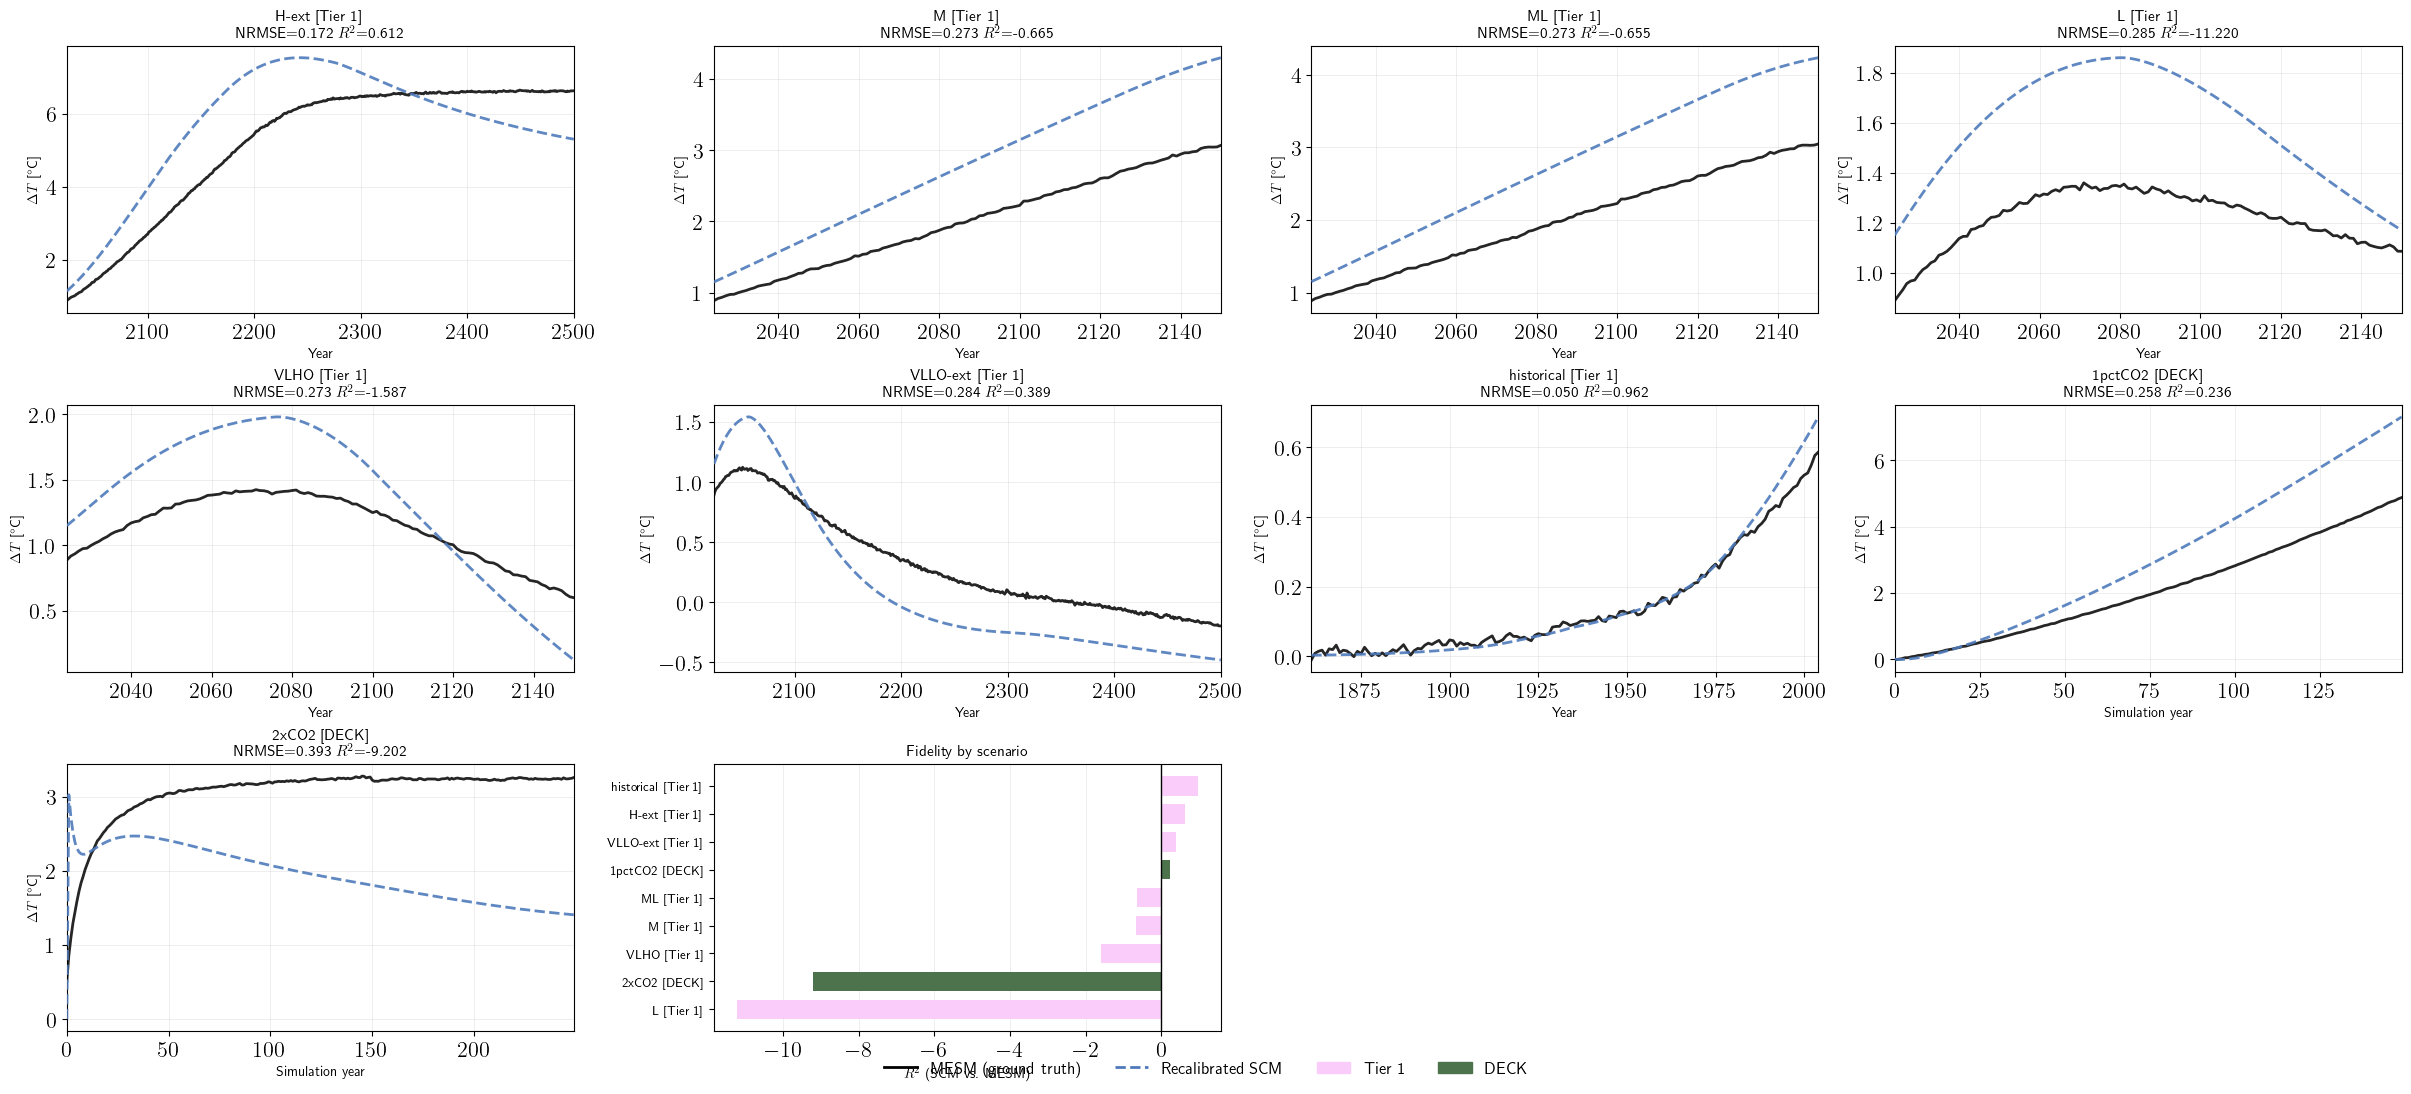

In [5]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_before, ncols=4, save="fig_calib_MESM_tier1_before",
)

### After: the new Tier1-joint stage

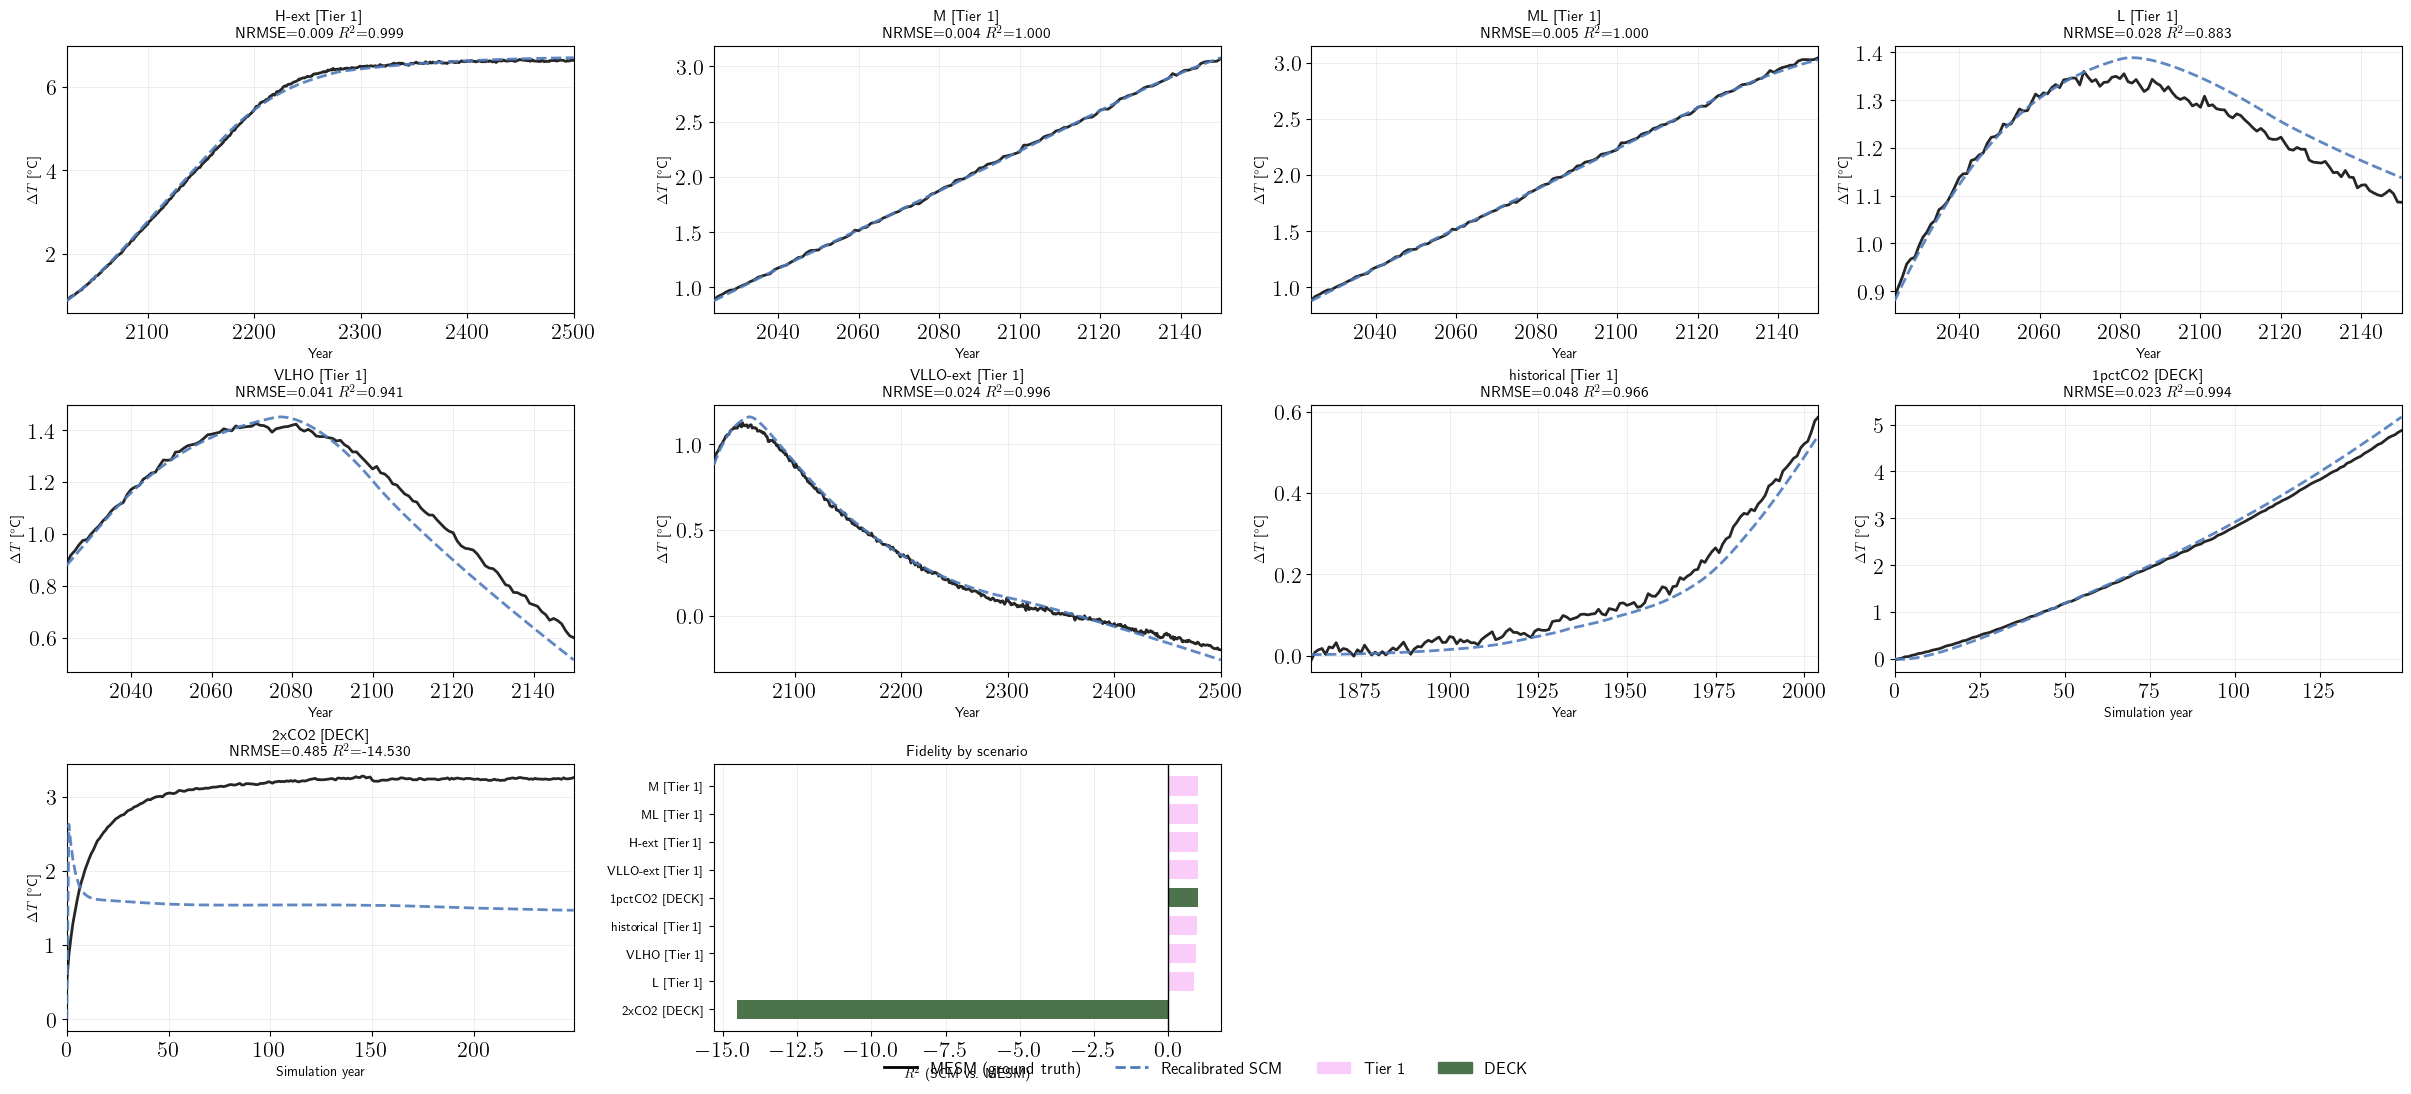

In [6]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_after, ncols=4, save="fig_calib_MESM_tier1_after",
)

## 4. Summary table: NRMSE/R² per scenario, before vs. after

In [7]:
rows = []
for pb, pa in zip(panels_before, panels_after):
    rows.append({
        "scenario": pb["scenario"],
        "nrmse_before": pb["nrmse"], "nrmse_after": pa["nrmse"],
        "r2_before": pb["r2"], "r2_after": pa["r2"],
    })
df = pd.DataFrame(rows)
df["nrmse_change_pct"] = 100 * (df["nrmse_after"] - df["nrmse_before"]) / df["nrmse_before"]

mean_row = pd.DataFrame([{
    "scenario": "— length-weighted mean —",
    "nrmse_before": np.average(df["nrmse_before"], weights=[len(p["x"]) for p in panels_before]),
    "nrmse_after": np.average(df["nrmse_after"], weights=[len(p["x"]) for p in panels_after]),
    "r2_before": df["r2_before"].mean(), "r2_after": df["r2_after"].mean(),
    "nrmse_change_pct": np.nan,
}])
pd.concat([df, mean_row], ignore_index=True)

,scenario,nrmse_before,nrmse_after,r2_before,r2_after,nrmse_change_pct
0,H-ext,0.171735,0.008644,0.611872,0.999017,-94.966659
1,M,0.272822,0.003810,-0.665395,0.999675,-98.603466
2,ML,0.273289,0.004520,-0.655453,0.999547,-98.346119
3,L,0.285160,0.027850,-11.219576,0.883442,-90.233430
4,VLHO,0.273314,0.041134,-1.586891,0.941405,-84.949863
5,VLLO-ext,0.283558,0.023712,0.389376,0.995730,-91.637814
6,historical,0.050497,0.048138,0.962452,0.965879,-4.672740
7,1pctCO2,0.258105,0.023359,0.235997,0.993742,-90.949885
8,2xCO2,0.393355,0.485311,-9.202218,-14.529832,23.377533
9,— length-weighted mean —,0.250141,0.078273,-2.347760,-0.750155,NaN


## Caveats to carry forward

- **Scope, by design**: only the Carbon and Climate theta groups move in the
  new stage. Aerosol (`f2_SO2`, `f2_BC`, `f1_aci`, `C0_SO2`, `f2_aci`) and
  gas-specific CH4/N2O theta fields stay at their `theta0` (FaIR-derived)
  values throughout. With the CO2-only correction above, these groups are not
  merely left untuned - their input emissions are zero-filled, so they are
  never exercised by the forward pass at all in this stage. Calibrating them
  would need real multi-agent MESM ground truth, which does not exist for
  Tier 1 (see the intro markdown); it remains its own scoped follow-up.
- **`historical`'s alignment fix is local to this notebook.** It does not
  retroactively correct `6k_scm_mesm_fidelity_plot.ipynb` or the published
  Additional Major Point 4 `historical` NRMSE/R² - those still compare the
  wrong 144-year window. Worth a deliberate follow-up fix, not a silent one.
- **9 scenarios (7 Tier 1 + DECK's `1pctCO2`/`2xCO2`), 3 free theta groups is
  still a small, tightly-scoped fit** - not a claim that this recovers a
  globally optimal MESM calibration. Adding `2xCO2` does mean the carbon
  cycle's pulse response is no longer entirely untested (see the module
  docstring's diagnosis of the earlier Tier1-only fit's `2xCO2` failure), but
  a single pulse scenario is still a thin basis for the 4-pool carbon-cycle
  partition - worth treating as a first pass, not a settled answer.

## 5. Postage stamp: `theta_tier1` against Tier 1 + Tier 2 + DECK + CS3

Everything above scores `theta_tier1` only against the 9 scenarios it was
*trained* on (7 Tier 1 scenarios + DECK's `1pctCO2`/`2xCO2`, all CO2-only).
This section evaluates the same `theta_tier1` on Stage 6d's full grid - Tier
1 + Tier 2 + DECK + CS3, 16 scored scenarios in total - to see how the fit
generalizes. **Note DECK is no longer purely held-out**: `1pctCO2`/`2xCO2`
are now part of the training set (added specifically to fix the pulse-
response gap the earlier Tier1-only fit had on `2xCO2`), so DECK's panels
here are a partial train/test overlap, not a clean generalization test.
Tier 2 and CS3 remain genuinely held out - neither was seen during
calibration.

**Scope note:** this section runs the SCM **CO2-only** (`agents=['CO2']`)
throughout, for all four families, matching `scripts/6d_scm_mesm_fidelity.py`'s
and `6k_scm_mesm_fidelity_plot.ipynb`'s own established convention - and also
matching Section 2-4's own CO2-only driving, so Tier 1 and DECK's panels here
are on the *same* input regime as training, not a regime shift.
This section's Tier 1/DECK numbers are still not expected to match Section
2-4's exactly: they go through Stage 6d's own `build_eval_sets` /
`mesm_global_truth_by_scenario` construction (a second, independent
implementation) rather than `build_tier1_dataset`'s, so this doubles as a
cross-check between the two pipelines, not just a re-statement of the same
numbers.

`build_eval_sets`, `mesm_global_truth_by_scenario`, and `nrmse_r2` are
reused from `6d_scm_mesm_fidelity.py` unchanged; only the SCM forward pass
is new, since `theta_tier1` needs to be injected as an explicit `params`
dict (Stage 6d's own `scm_gmst_by_scenario` always uses the mode-based
default MESM params, not a custom theta).

Same `historical`-alignment fix as Section 3 is applied here too, for Tier
1's `historical` panel only (the only family where `historical` is scored) -
still local to this notebook, still not propagated back into
`6d_scm_mesm_fidelity.py` or `6k_scm_mesm_fidelity_plot.ipynb`.

The figure below now includes a legend for the scenario-set colours in the
trailing fidelity-summary bar panel (`utils_plotting.plot_scm_mesm_fidelity_grid`
was updated to add this).


In [8]:
def scm_gmst_by_scenario_theta(emis_dict, theta, agents=("CO2",), mode="MESM"):
    """Same per-scenario history-handling logic as
    utils_inverse.build_dataset_from_runfair_dict, but injects an explicit
    `params` dict built from `theta` instead of relying on
    simulate_targets_gmst's own mode-based default lookup - this is what
    lets theta_tier1 drive Stage 6d's CO2-only eval sets."""
    params = utils_FaIR_JAX.params_from_theta(theta, base_params=utils_FaIR_JAX.MESM_PARAMS)

    years_hist, emis_hist_dict = (None, None)
    if "historical" in emis_dict:
        years_hist, emis_hist_dict = utils_inverse.extract_years_and_emis(
            emis_dict["historical"], agents=agents
        )

    out = {}
    skip_hist = False
    for scen in emis_dict:
        if skip_hist and scen == "historical":
            continue
        if scen == "historical" and not skip_hist:
            skip_hist = True

        yrs_cur, emis_cur_dict = utils_inverse.extract_years_and_emis(emis_dict[scen], agents=agents)
        needs_history = (
            scen != "historical" and years_hist is not None and scen in utils_inverse.scens_with_hist
        )

        yh, eh = years_hist, emis_hist_dict
        if needs_history:
            yh, eh = utils_inverse.CS3_hist_modifier(scen, years_hist, emis_hist_dict)

        # BUGFIX: `agents` must NOT be truncated here -- a 1-row emissions array
        # makes simulate_temp read rows 1..4 out of bounds, which JAX clamps to
        # row 0, feeding the CO2 series in as CH4/N2O/sulfur/BC as well. Left at
        # the 5-agent default so absent agents are zero-filled (see
        # scripts/2d_calibrate_MESM_alt.py's matching fix).
        pred = utils_inverse.simulate_targets_gmst(
            years_curr=yrs_cur, emis_curr_dict=emis_cur_dict,
            years_hist=(yh if needs_history else None),
            emis_hist_dict=(eh if needs_history else None),
            mode=mode, params=params,
        )
        out[scen] = np.asarray(pred)
    return out


eval_emis_sets_all, eval_targets_sets_all, lat_coords_all = s6d.build_eval_sets()

scm_gmst_tier1joint, mesm_truth_all = {}, {}
for set_name, emis_d in eval_emis_sets_all.items():
    targets_d = eval_targets_sets_all.get(set_name)
    if targets_d is None:
        print(f"[{set_name}] no MESM targets found, skipping")
        continue
    scm_gmst_tier1joint[set_name] = scm_gmst_by_scenario_theta(emis_d, theta_tier1)
    mesm_truth_all[set_name] = s6d.mesm_global_truth_by_scenario(emis_d, targets_d, lat_coords_all)
    print(f"[{set_name}] {sorted(scm_gmst_tier1joint[set_name])}")


[Tier 1] ['H-ext', 'L', 'M', 'ML', 'VLHO', 'VLLO-ext', 'historical']


[Tier 2] ['H-ext-OS', 'L-ext', 'M-ext', 'ML-ext', 'VLHO-ext', 'historical']


[CS3] ['AA', 'CT', 'historical']
[All] no MESM targets found, skipping


[DECK] ['1pctCO2', '2xCO2']


In [9]:
CALENDAR_SETS = {"Tier 1", "Tier 2"}   # 2024-anchored (or 1861 for `historical`)
SIM_YEAR_SETS = {"DECK", "CS3"}        # idealized experiments, no calendar anchor

panels_all_families = []
for set_name in ["Tier 1", "Tier 2", "DECK", "CS3"]:
    for scen, scm_arr in scm_gmst_tier1joint[set_name].items():
        if scen == "historical" and set_name != "Tier 1":
            continue  # matches Stage 6d's own scoring exclusion

        truth_arr = mesm_truth_all[set_name].get(scen)
        if truth_arr is None:
            print(f"[{set_name}/{scen}] no MESM truth, skipping")
            continue

        scm_arr = np.asarray(scm_arr)
        truth_arr = np.asarray(truth_arr)

        if scen == "historical":
            # Same MESM-1861-start fix as Section 2/3: 6d/6k's own historical
            # panel compares the wrong window (see intro markdown).
            scm_arr = scm_arr[s2d.EMIS_OFFSET_HIST:]

        nrmse, r2, n = s6d.nrmse_r2(scm_arr, truth_arr)
        scm_arr, truth_arr = scm_arr[:n], truth_arr[:n]

        if set_name in CALENDAR_SETS:
            start = 1861 if scen == "historical" else 2024
            x = np.arange(start, start + n)
            xlabel = "Year"
        else:
            x = np.arange(n)
            xlabel = "Simulation year"

        panels_all_families.append(dict(
            set_name=set_name, scenario=scen, x=x, xlabel=xlabel,
            scm=scm_arr, mesm=truth_arr, nrmse=nrmse, r2=r2,
        ))

print(f"{len(panels_all_families)} panels")


16 panels


### The postage-stamp figure

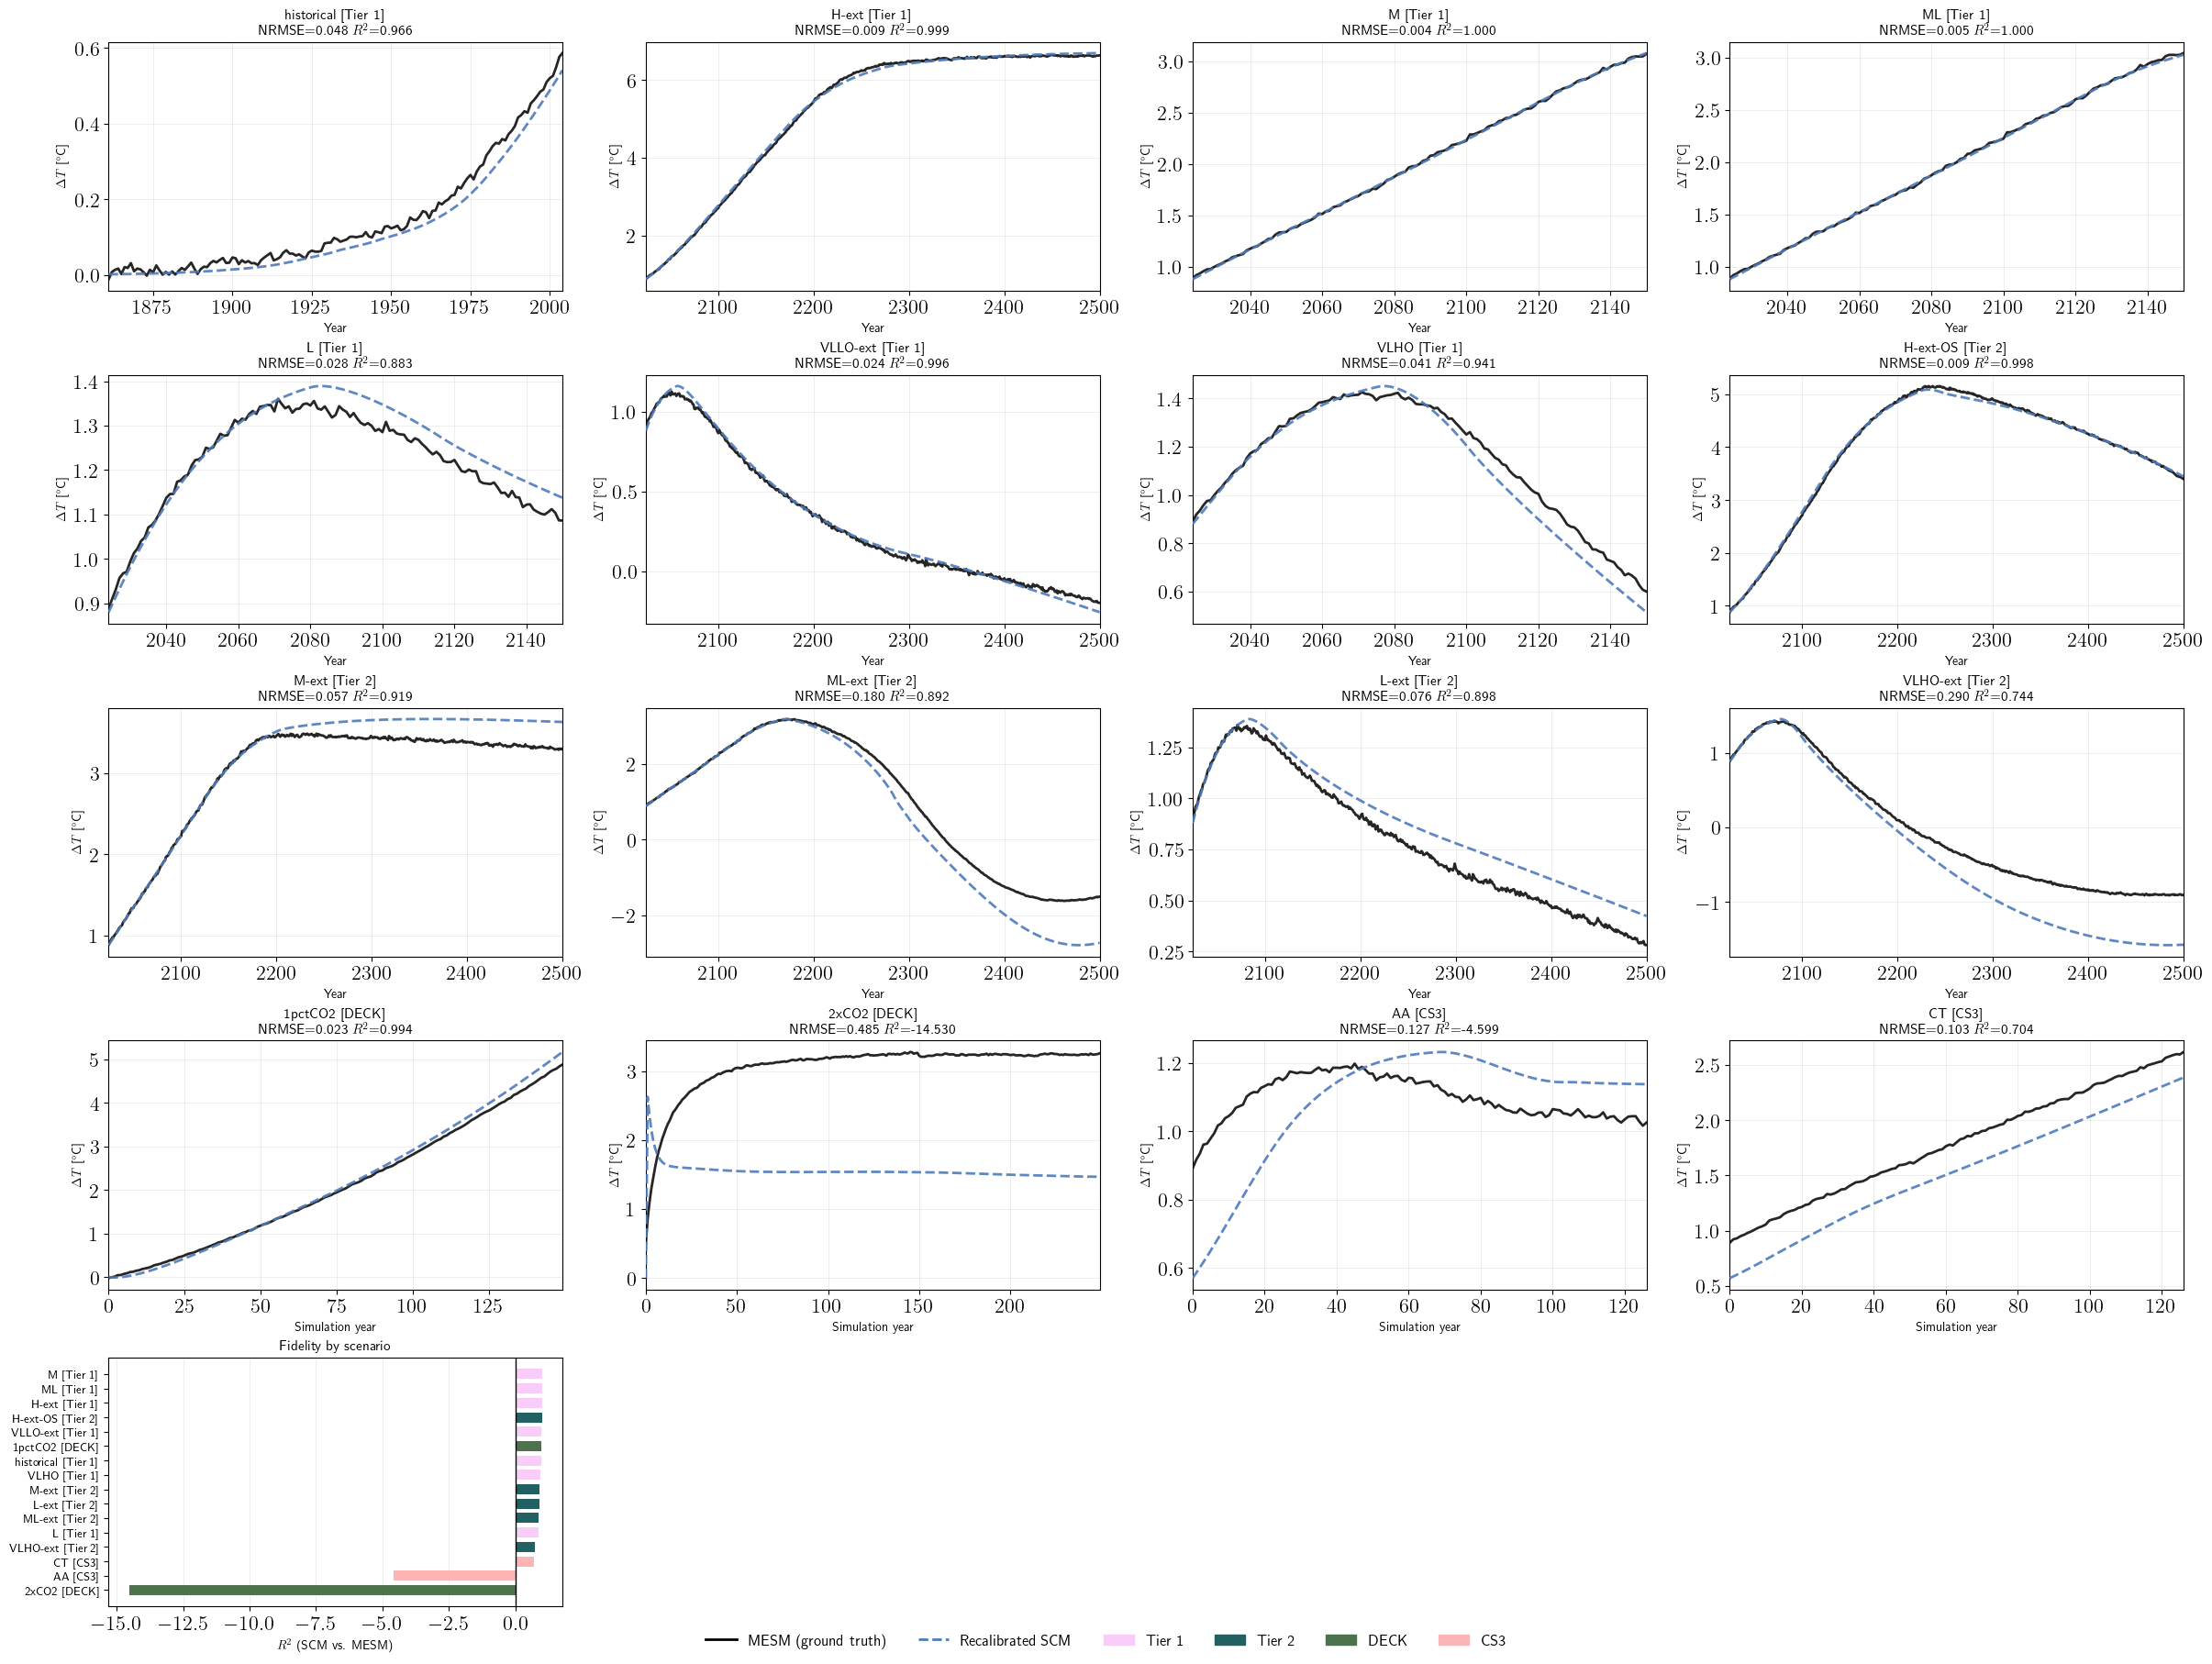

In [10]:
fig, axes = utils_plotting.plot_scm_mesm_fidelity_grid(
    panels_all_families, ncols=4, save="fig_calib_MESM_tier1joint_all_families",
)


### Summary table: NRMSE/R² per scenario, all four families

In [11]:
df_all = pd.DataFrame([{k: p[k] for k in ("set_name", "scenario", "nrmse", "r2")} for p in panels_all_families])
df_all = df_all.sort_values(["set_name", "scenario"]).reset_index(drop=True)

means_all = df_all.groupby("set_name")[["nrmse", "r2"]].mean().reset_index()
means_all["scenario"] = "— mean —"

summary_all = pd.concat([df_all, means_all], ignore_index=True).sort_values(
    ["set_name", "scenario"], key=lambda s: s.map(lambda v: (v != "— mean —", v))
)
overall_all = pd.DataFrame([{
    "set_name": "ALL", "scenario": "— overall mean —",
    "nrmse": df_all["nrmse"].mean(), "r2": df_all["r2"].mean(),
}])
pd.concat([summary_all, overall_all], ignore_index=True)


,set_name,scenario,nrmse,r2
0,CS3,— mean —,0.115095,-1.947597
1,CS3,AA,0.127362,-4.598734
2,CS3,CT,0.102828,0.703540
3,DECK,— mean —,0.254335,-6.768045
4,DECK,1pctCO2,0.023359,0.993742
5,DECK,2xCO2,0.485311,-14.529833
6,Tier 1,— mean —,0.022544,0.969242
7,Tier 1,H-ext,0.008644,0.999017
8,Tier 1,L,0.027850,0.883442
9,Tier 1,M,0.003810,0.999675
